In [15]:
import pandas as pd
import numpy as np

In [16]:
df = pd.read_csv("Messy_Employee_dataset.csv")

df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [17]:
print("Rows and Columns :", df.shape)

Rows and Columns : (1020, 12)


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   str    
 1   First_Name         1020 non-null   str    
 2   Last_Name          1020 non-null   str    
 3   Age                809 non-null    float64
 4   Department_Region  1020 non-null   str    
 5   Status             1020 non-null   str    
 6   Join_Date          1020 non-null   str    
 7   Salary             996 non-null    float64
 8   Email              1020 non-null   str    
 9   Phone              1020 non-null   int64  
 10  Performance_Score  1020 non-null   str    
 11  Remote_Work        1020 non-null   bool   
dtypes: bool(1), float64(2), int64(1), str(8)
memory usage: 88.8 KB


In [19]:
df.isnull().sum()

Employee_ID            0
First_Name             0
Last_Name              0
Age                  211
Department_Region      0
Status                 0
Join_Date              0
Salary                24
Email                  0
Phone                  0
Performance_Score      0
Remote_Work            0
dtype: int64

In [20]:
average_age = np.mean(df["Age"])

df["Age"] = df["Age"].fillna(average_age)

In [21]:
average_salary = np.mean(df["Salary"])

df["Salary"] = df["Salary"].fillna(average_salary)

In [22]:
df.isnull().sum()

Employee_ID          0
First_Name           0
Last_Name            0
Age                  0
Department_Region    0
Status               0
Join_Date            0
Salary               0
Email                0
Phone                0
Performance_Score    0
Remote_Work          0
dtype: int64

In [23]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [24]:
df.dtypes

Employee_ID              str
First_Name               str
Last_Name                str
Age                  float64
Department_Region        str
Status                   str
Join_Date                str
Salary               float64
Email                    str
Phone                  int64
Performance_Score        str
Remote_Work             bool
dtype: object

In [25]:
df["Join_Date"] = pd.to_datetime(df["Join_Date"])

df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.000000,DevOps-California,Active,2021-04-02,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,32.484549,Finance-Texas,Active,2020-07-10,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,32.484549,Admin-Nevada,Pending,2023-12-07,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.000000,Admin-Nevada,Inactive,2021-11-27,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.000000,Cloud Tech-Florida,Active,2022-01-05,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [28]:
df.to_csv("Cleaned_Employee_Dataset.csv", index=False)

print("Dataset Cleaned Successfully")

Dataset Cleaned Successfully


### Matplotlib and Seaborn

#### 1. Histogram – Employee Age Distribution

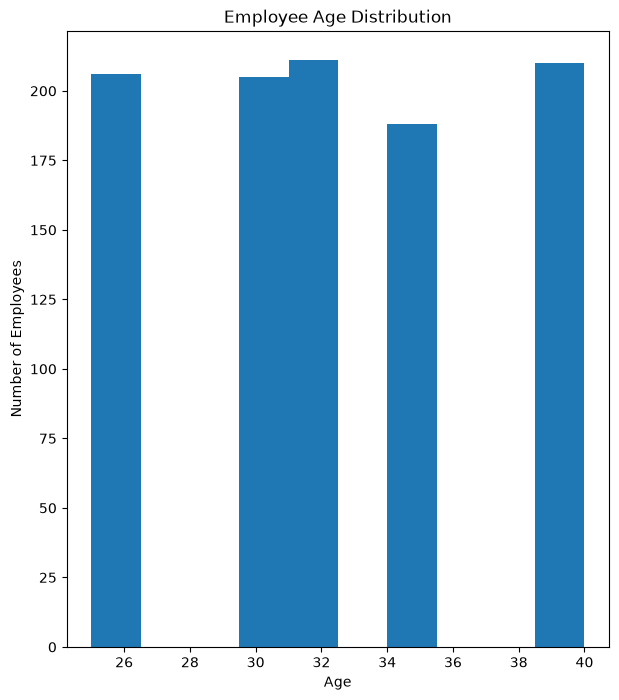

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,8))
plt.hist(df["Age"], bins=10)

plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

#### 2. Pie Chart – Top 5 Department Regions

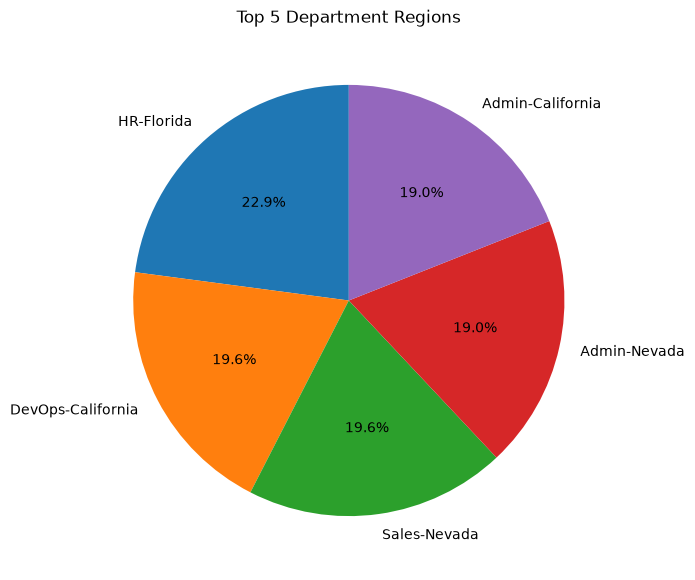

In [31]:
top_region = df["Department_Region"].value_counts().head(5)

plt.figure(figsize=(7,7))

plt.pie(top_region.values,
        labels=top_region.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Top 5 Department Regions")

plt.show()

#### 3. Count Plot (Seaborn) – Employee Status Count

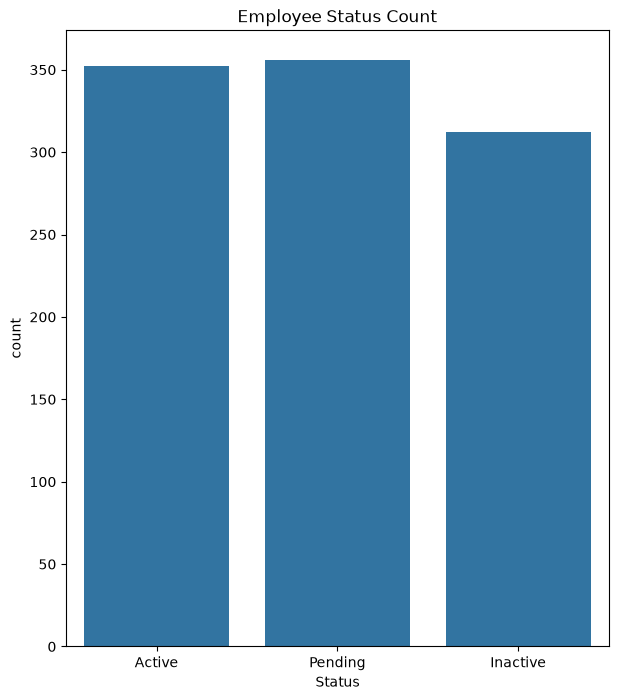

In [56]:
import seaborn as sns

plt.figure(figsize=(7,8))
sns.countplot(data=df, x="Status")

plt.title("Employee Status Count")

plt.show()

#### 4. Histogram + KDE – Salary Distribution

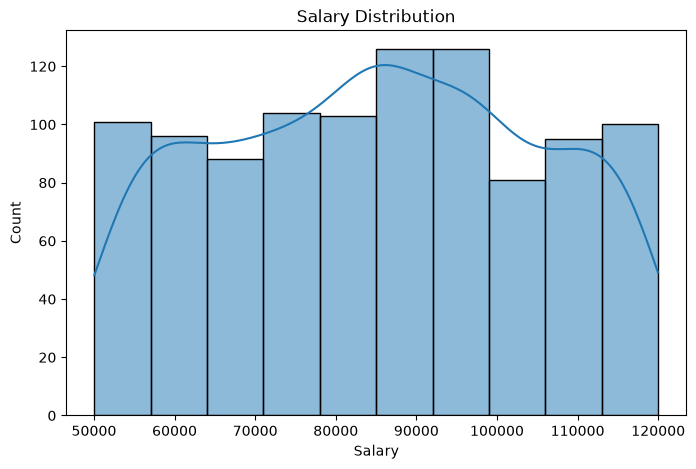

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salary"], bins=10, kde=True)

plt.title("Salary Distribution")

plt.show()

#### 5. Line Plot – Salary vs Performance Score (Top 10)

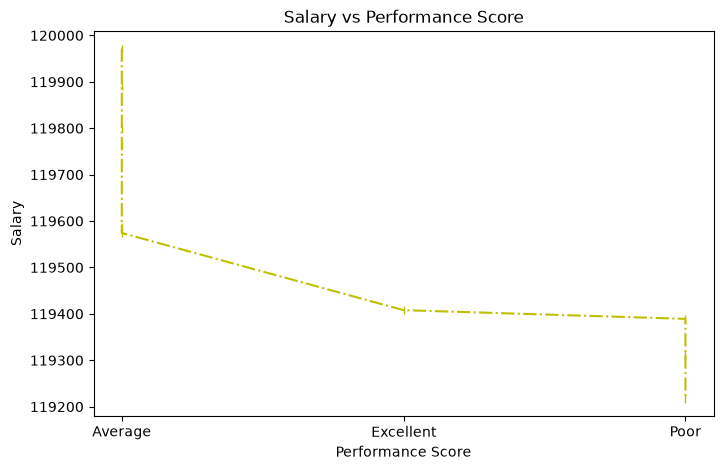

In [44]:
import matplotlib.pyplot as plt

# Top 10 employees based on Salary
top10 = df.nlargest(10, "Salary")

plt.figure(figsize=(8,5))

plt.plot(top10["Performance_Score"],
         top10["Salary"],
         linestyle="-.",
         marker="|",
         color="y")

plt.title("Salary vs Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Salary")

plt.show()

#### 6. Horizontal Bar Chart – Employees by Department Region

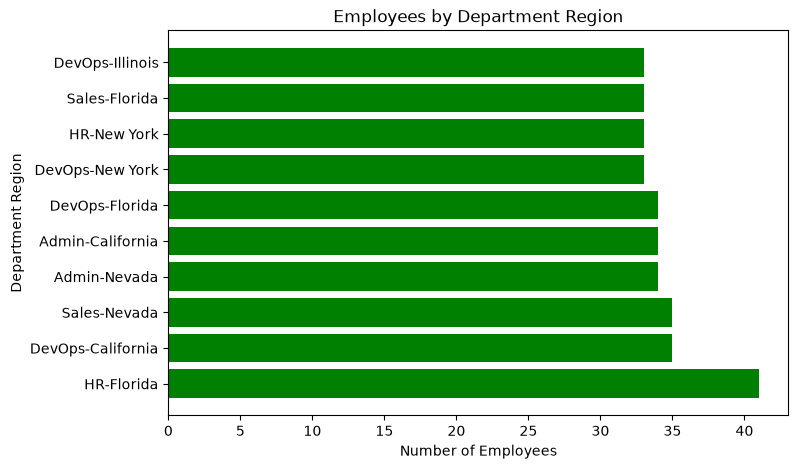

In [59]:
import matplotlib.pyplot as plt

region = df["Department_Region"].value_counts().head(10)

plt.figure(figsize=(8,5))

plt.barh(region.index, region.values, color="green")

plt.title("Employees by Department Region")
plt.xlabel("Number of Employees")
plt.ylabel("Department Region")

plt.show()